In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_path = "/content/student_performance_updated_1000.csv"
data = pd.read_csv(file_path)

In [3]:
print("First 5 rows:")
print(data.head())

First 5 rows:
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1          2.2    

In [4]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB
None


In [5]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


In [6]:
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    data[col] = data[col].fillna(data[col].mean())

In [7]:
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

/tmp/ipython-input-815288077.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(data[col].mode()[0])


In [8]:
print("\nAfter Handling Missing Values:")
print(data.isnull().sum())


After Handling Missing Values:
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64


In [9]:
print("Columns in dataset:", data.columns.tolist())


Columns in dataset: ['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


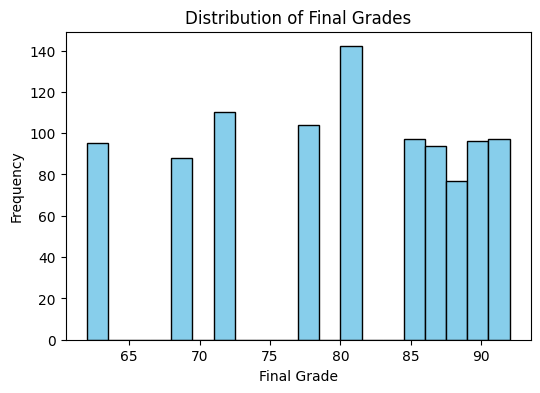

In [10]:
plt.figure(figsize=(6,4))
plt.hist(data['FinalGrade'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.show()

In [11]:
print("\nBasic Statistics:")
print(data.describe())


Basic Statistics:
         StudentID  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
count  1000.000000     1000.000000        1000.000000    1000.000000   
mean   5416.019792       85.510417          17.630526      77.598759   
std    2600.077491        7.183836           6.113157       9.839977   
min       1.000000       70.000000           8.000000      60.000000   
25%    3246.750000       82.000000          12.000000      70.000000   
50%    5416.019792       85.510417          17.630526      78.000000   
75%    7667.500000       91.000000          22.000000      86.000000   
max    9998.000000       95.000000          30.000000      90.000000   

       ExtracurricularActivities   FinalGrade  Study Hours  Attendance (%)  
count                1000.000000  1000.000000  1000.000000     1000.000000  
mean                    1.520376    80.030208     2.406967       77.248175  
std                     1.023670     9.301647     1.600686       18.897991  
min                     

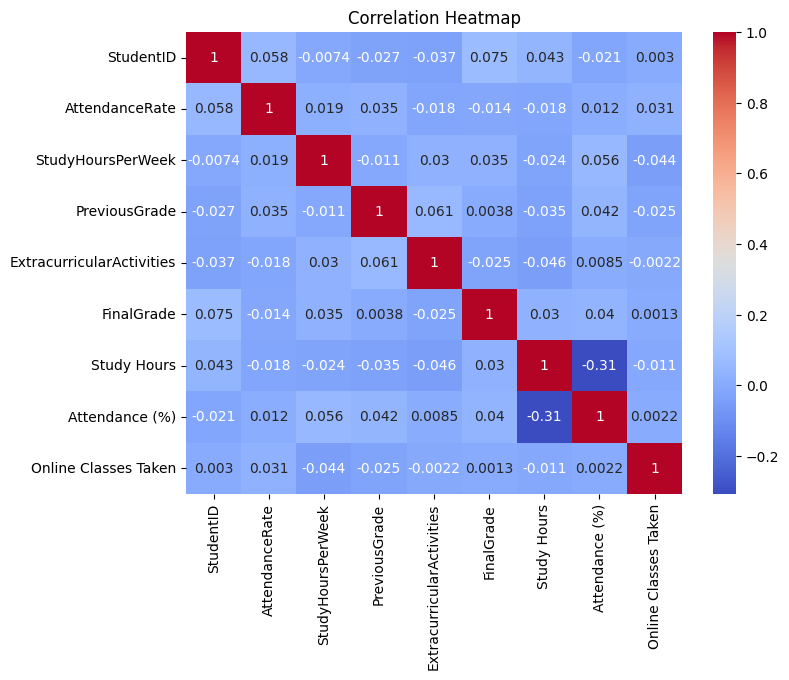

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
avg_final_gender = data.groupby('Gender')['FinalGrade'].mean()
print("\nAverage Final Grade by Gender:")
print(avg_final_gender)


Average Final Grade by Gender:
Gender
Female    80.460454
Male      79.676765
Name: FinalGrade, dtype: float64


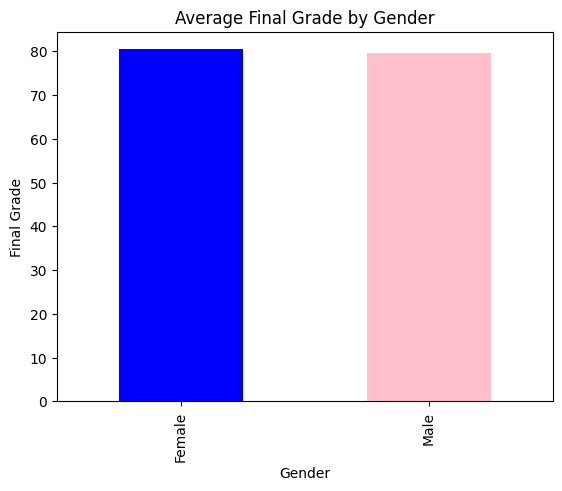

In [14]:
avg_final_gender.plot(kind='bar', color=['blue','pink'])
plt.title("Average Final Grade by Gender")
plt.ylabel("Final Grade")
plt.show()

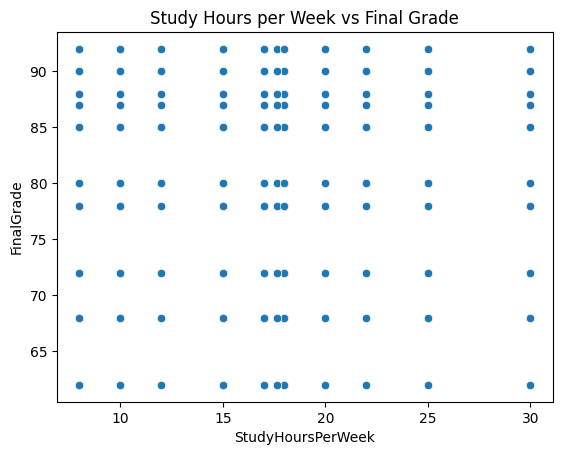

In [15]:
sns.scatterplot(x='StudyHoursPerWeek', y='FinalGrade', data=data)
plt.title("Study Hours per Week vs Final Grade")
plt.show()

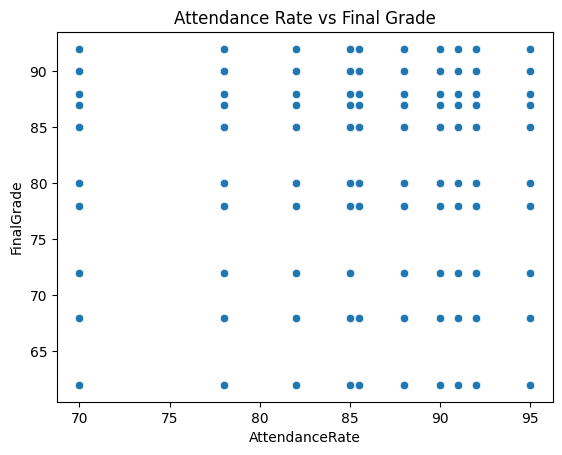

In [16]:
# Relationship: Attendance Rate vs Final Grade
sns.scatterplot(x='AttendanceRate', y='FinalGrade', data=data)
plt.title("Attendance Rate vs Final Grade")
plt.show()

In [17]:
# Create new feature: Pass/Fail based on FinalGrade
threshold = 50
data['pass_fail'] = data['FinalGrade'].apply(lambda x: 'Pass' if x >= threshold else 'Fail')

In [18]:
# Create normalized version of grades and attendance
data['FinalGrade_norm'] = (data['FinalGrade'] - data['FinalGrade'].min()) / (data['FinalGrade'].max() - data['FinalGrade'].min())
data['AttendanceRate_norm'] = (data['AttendanceRate'] - data['AttendanceRate'].min()) / (data['AttendanceRate'].max() - data['AttendanceRate'].min())

In [19]:
print("\nNew Features Added:")
print(data.head())


New Features Added:
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male       85.000000               15.0   
1        2.0    Sarah  Female       90.000000               20.0   
2        3.0     Alex    Male       78.000000               10.0   
3        4.0  Michael    Male       92.000000               25.0   
4        5.0     Emma  Female       85.510417               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%)  Online Classes Taken pass_fail  \
0          4.8            59.0                 False 

In [20]:
data.to_csv('processed_student_performance.csv', index=False)
print("Processed dataset saved as 'processed_student_performance.csv'")

Processed dataset saved as 'processed_student_performance.csv'
